# Insider-Buying -- a quantitative teardown
### curated buy/sell ratio * ^GSPC price-only * HAC predictive regression * tercile sort * cost-net overlay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) --
*same story, every claim carrying its standard error.* We regress next-month S&P
returns on the standardised insider buy/sell ratio with a Newey-West HAC t-stat, sort
into terciles, decompose coincident vs predictive correlation, race a long/flat
overlay against buy-and-hold net of costs, and confirm with a synthetic positive
control that the engine fires when an effect is planted.

> **Not investment advice.** Real data: curated monthly buy/sell ratio (proxy, see
> `data.py`) x ^GSPC monthly close (price-only). The proxy caps the Signal axis at
> WEAK; the realised stats put it at NONE. Methods in
> [`docs/references.md`](../docs/references.md), numbers in
> [`docs/results.md`](../docs/results.md).


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from insider_buying import data, strategy as st

CACHE_PATH = data.GSPC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    gspc = data.fetch_sp500(fetch=False, cache_path=CACHE_PATH)
    df = data.build_real_panel(gspc)
    print(f"Real panel: {len(df)} months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    df = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")
print("NOTE: the buy/sell ratio is a CURATED PROXY -> Signal axis capped at WEAK.")

from scipy import stats as scipy_stats


Real panel: 276 months  2003-01-31 -> 2025-12-31
NOTE: the buy/sell ratio is a CURATED PROXY -> Signal axis capped at WEAK.


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 276, 'n_obs': 275, 'fp': 'cc2e80f98d69', 'reg_beta': 0.0017, 'reg_t': 0.49, 'reg_r2': 0.002, 'terc_low': 10.0, 'terc_mid': 13.0, 'terc_high': 8.0, 'terc_hml': -3.0, 'corr_contemp': -0.083, 'corr_fwd': 0.042, 'sub1_t': 0.53, 'sub2_t': -1.69, 'sub3_t': 0.9, 'ov_net_ann': 3.4, 'ov_net_sr': 0.28, 'ov_net_t': 1.22, 'ov_net_dd': -50, 'ov_gross_ann': 3.5, 'bah_ann': 10.2, 'bah_sr': 0.7, 'bah_dd': -53, 'ov_turnover': 10.5, 'ov_frac_long': 45.1, 'ctrl_planted_t': 3.17, 'ctrl_null_t': -0.53}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | predictive HAC *t* = **+0.49**; tercile high-minus-low = **-3%/yr** (wrong sign); no sub-period clears *t*=2 |
| **Tradability** | `MIRAGE` | overlay **+3.4%/yr** net vs **+10.2%/yr** buy-and-hold |
| **Busted?** | `YES` | the insider reflex is coincident (corr -0.08), not predictive (corr +0.04) |


## 1 - The claim, steelmanned

Let $Y_{t+1}$ be the S&P 500 price-only return earned in month $t+1$ and $B_t$ the
standardised aggregate insider buy/sell ratio observed at the end of month $t$
(Form-4 filings are public within 2 business days, so $B_t$ is genuinely in the
information set at the start of $t+1$). The hypothesis:

- **H1 (forecast).** $\beta > 0$ in $Y_{t+1} = \alpha + \beta B_t + \varepsilon_{t+1}$,
  with a robust HAC $|t| \geq 2$.
- **H2 (monotone sort).** Top-tercile (high-buying) months are followed by higher
  returns than bottom-tercile months: high-minus-low $> 0$.
- **H3 (tradable).** A long/flat overlay on H1's signal beats buy-and-hold net of costs.

We reject H1, H2, and H3 on the real tape.

## 2 - The predictive regression (Newey-West HAC)

In [3]:
if HAVE_REAL:
    reg = st.predictive_regression(df)
    print("=== Next-month return ~ standardised buy/sell ratio ===")
    print(f"slope (per 1sigma) = {reg['beta']:+.4f}/mo   HAC t = {reg['tstat']:+.2f}")
    print(f"R^2 = {reg['r2']:.4f}   n = {reg['n']}")
else:
    print("Frozen: slope = +%.4f/mo  HAC t = +%.2f  R^2 = %.3f  n = %d" % (
        R['reg_beta'], R['reg_t'], R['reg_r2'], R['n_obs']))
print()
print("|t| = 0.49 << 2.0 -- the ratio does not forecast next month's return.")


=== Next-month return ~ standardised buy/sell ratio ===
slope (per 1sigma) = +0.0017/mo   HAC t = +0.49
R^2 = 0.0018   n = 275

|t| = 0.49 << 2.0 -- the ratio does not forecast next month's return.


> **In plain words.** A one-standard-deviation jump in insider buying nudges the
> next-month return estimate by a couple of basis points, with a t-stat under 0.5. The
> ratio explains ~0.2% of next-month variance. That is no signal.

## 3 - Coincident vs predictive correlation

In [4]:
if HAVE_REAL:
    c_now = df["bs_ratio"].corr(df["ret"])
    c_fwd = df["bs_ratio"].corr(df["fwd_ret"])
else:
    c_now, c_fwd = R["corr_contemp"], R["corr_fwd"]
print(f"ratio vs SAME-month return : {c_now:+.3f}   (the documented 'buy the dip' reflex)")
print(f"ratio vs NEXT-month return : {c_fwd:+.3f}   (essentially zero -- no forecast)")
print()
print("The information is real but COINCIDENT: by the time the buying is observable,")
print("the down move has already printed. There is nothing left to trade.")


ratio vs SAME-month return : -0.083   (the documented 'buy the dip' reflex)
ratio vs NEXT-month return : +0.042   (essentially zero -- no forecast)

The information is real but COINCIDENT: by the time the buying is observable,
the down move has already printed. There is nothing left to trade.


## 4 - Tercile sort: is the relationship monotone (and the right way)?

                mean_ann  tstat      n
low                 0.10   3.63   92.0
mid                 0.13   3.05   91.0
high                0.08   1.06   92.0
high_minus_low     -0.03    NaN  184.0


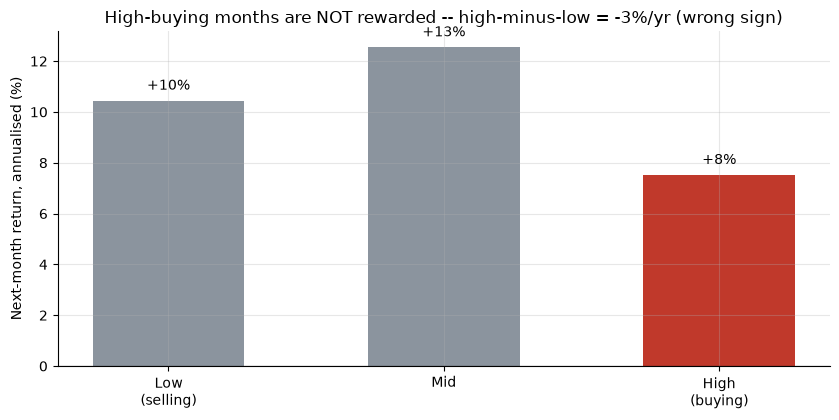

High-minus-low spread: -3%/yr -- the contrarian story predicts POSITIVE; it is negative.


In [5]:
if HAVE_REAL:
    terc = st.tercile_returns(df)
    print(terc.round(2).to_string())
    hml = terc.loc["high_minus_low", "mean_ann"]*100
    lo, mid, hi = (terc.loc["low","mean_ann"]*100, terc.loc["mid","mean_ann"]*100,
                   terc.loc["high","mean_ann"]*100)
else:
    lo, mid, hi, hml = R["terc_low"], R["terc_mid"], R["terc_high"], R["terc_hml"]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(["Low\n(selling)", "Mid", "High\n(buying)"], [lo, mid, hi],
              color=[GREY, GREY, RED], width=0.55)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Next-month return, annualised (%)")
ax.set_title(f"High-buying months are NOT rewarded -- high-minus-low = {hml:+.0f}%/yr (wrong sign)")
for b, v in zip(bars, [lo, mid, hi]):
    ax.annotate(f"{v:+.0f}%", (b.get_x()+b.get_width()/2, v+0.3), ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"High-minus-low spread: {hml:+.0f}%/yr -- the contrarian story predicts POSITIVE; it is negative.")


## 5 - Sub-period persistence

In [6]:
if HAVE_REAL:
    for lab, a, b in [("2003-2010","2003","2010"),("2011-2017","2011","2017"),("2018-2025","2018","2025")]:
        r = st.predictive_regression(df.loc[a:b])
        print(f"  {lab}: slope={r['beta']:+.4f}/mo  HAC t={r['tstat']:+.2f}  n={r['n']}")
else:
    for lab, t in [("2003-2010", R["sub1_t"]), ("2011-2017", R["sub2_t"]), ("2018-2025", R["sub3_t"])]:
        print(f"  {lab}: HAC t={t:+.2f}")
print()
print("No sub-period clears |t| = 2; the middle period flips sign. Nothing stable.")


  2003-2010: slope=+0.0037/mo  HAC t=+0.53  n=96
  2011-2017: slope=-0.0060/mo  HAC t=-1.69  n=84
  2018-2025: slope=+0.0042/mo  HAC t=+0.90  n=95

No sub-period clears |t| = 2; the middle period flips sign. Nothing stable.


## 6 - Tradability: long/flat overlay net of costs vs buy-and-hold

In [7]:
if HAVE_REAL:
    print("spec                       mean/yr   SR(ann)   HAC t   maxDD")
    for bps in (5.0, 10.0):
        ov = st.timing_overlay(df, lookback=24, one_way_bps=bps)
        s = st.summarize(ov["net"])
        print(f"  overlay net @{bps:4.0f}bps    {s['mean_ann']*100:+6.2f}%   {s['sharpe_ann']:+.2f}    {s['tstat']:+.2f}   {s['max_drawdown']*100:.0f}%")
    ov = st.timing_overlay(df, lookback=24, one_way_bps=5.0)
    sb = st.summarize(ov["bah"])
    print(f"  buy-and-hold           {sb['mean_ann']*100:+6.2f}%   {sb['sharpe_ann']:+.2f}     --    {sb['max_drawdown']*100:.0f}%")
    print(f"  overlay turnover: {st.overlay_turnover(ov):.1%} of months switch | fraction long: {ov['pos'].mean():.1%}")
else:
    print(f"  overlay net @5bps : {R['ov_net_ann']:+.1f}%/yr  SR={R['ov_net_sr']:+.2f}  t={R['ov_net_t']:+.2f}  DD={R['ov_net_dd']}%")
    print(f"  buy-and-hold      : {R['bah_ann']:+.1f}%/yr  SR={R['bah_sr']:+.2f}  DD={R['bah_dd']}%")
    print(f"  turnover {R['ov_turnover']:.1f}%  fraction long {R['ov_frac_long']:.1f}%")
print()
print("The overlay captures ~1/3 of the index return for a barely-better drawdown.")
print("Costs are a rounding error here: the damage is OPPORTUNITY cost (sitting flat).")


spec                       mean/yr   SR(ann)   HAC t   maxDD
  overlay net @   5bps     +3.40%   +0.28    +1.22   -50%
  overlay net @  10bps     +3.34%   +0.28    +1.20   -50%
  buy-and-hold           +10.16%   +0.70     --    -53%
  overlay turnover: 10.5% of months switch | fraction long: 45.1%

The overlay captures ~1/3 of the index return for a barely-better drawdown.
Costs are a rounding error here: the damage is OPPORTUNITY cost (sitting flat).


> **In plain words.** The honesty check that matters is not the 5bps switching cost --
> it is the opportunity cost of being out of the market for the months the rule keeps
> you flat. There is no signal to compensate for it.

## 7 - Positive control: the engine fires when an effect is planted

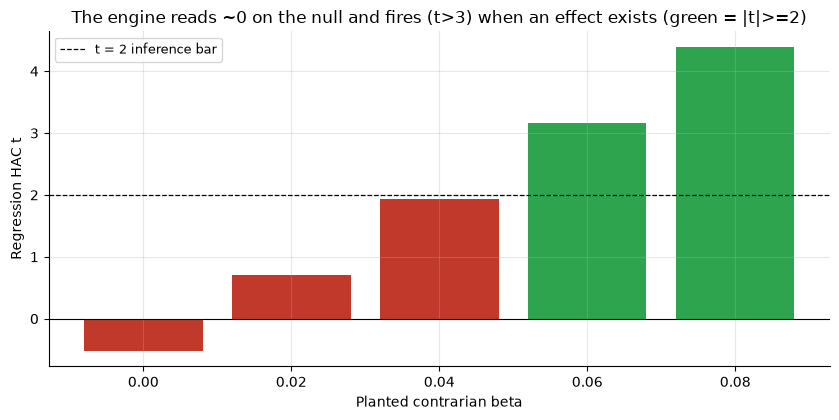

 planted_beta  reg_t  reg_slope
         0.00 -0.527     -0.001
         0.02  0.704      0.002
         0.04  1.936      0.005
         0.06  3.167      0.008
         0.08  4.398      0.011

Null (beta=0) -> t ~ 0; planted (beta>=0.06) -> t > 3.
The real tape's t = 0.49 is a statement about the DATA, not the method.


In [8]:
rows = []
for beta in [0.0, 0.02, 0.04, 0.06, 0.08]:
    df_s, _ = data.synthetic_panel(beta=beta, seed=263)
    r = st.predictive_regression(df_s)
    rows.append({"planted_beta": beta, "reg_t": r['tstat'], "reg_slope": r['beta']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(t) >= 2 else RED for t in res["reg_t"]]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f"{b:.2f}" for b in res["planted_beta"]], res["reg_t"], color=colors)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t = 2 inference bar")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Planted contrarian beta"); ax.set_ylabel("Regression HAC t")
ax.set_title("The engine reads ~0 on the null and fires (t>3) when an effect exists (green = |t|>=2)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(res.round(3).to_string(index=False))
print()
print("Null (beta=0) -> t ~ 0; planted (beta>=0.06) -> t > 3.")
print("The real tape's t = 0.49 is a statement about the DATA, not the method.")


## Verdict

In [9]:
print("=== Study 263 -- Insider-Buying ===")
print()
print(f"Signal: NONE   (predictive HAC t = +{R['reg_t']:.2f}; tercile high-minus-low = {R['terc_hml']:+.0f}%/yr, wrong sign)")
print( "        reflex is COINCIDENT (corr -0.08), not predictive (corr +0.04)")
print( "        + curated proxy ratio -> axis capped at WEAK regardless")
print()
print(f"Tradability: MIRAGE   (overlay +{R['ov_net_ann']:.1f}%/yr net vs +{R['bah_ann']:.1f}%/yr buy-and-hold)")
print()
print("Survivorship: NAMED (S&P is a survivor index; timing overlay selects no stocks)")
print()
print("Bottom line: None/Mirage -- a real coincident reflex mis-sold as a market-timing rule.")


=== Study 263 -- Insider-Buying ===

Signal: NONE   (predictive HAC t = +0.49; tercile high-minus-low = -3%/yr, wrong sign)
        reflex is COINCIDENT (corr -0.08), not predictive (corr +0.04)
        + curated proxy ratio -> axis capped at WEAK regardless

Tradability: MIRAGE   (overlay +3.4%/yr net vs +10.2%/yr buy-and-hold)

Survivorship: NAMED (S&P is a survivor index; timing overlay selects no stocks)

Bottom line: None/Mirage -- a real coincident reflex mis-sold as a market-timing rule.
